In [3]:
# ============================================================
# SETUP: Fix working directory first
# ============================================================
import os
from pathlib import Path

# Force correct working directory
PROJECT_DIR = r"C:\Users\User\Desktop\research\bengali-smishing"
os.chdir(PROJECT_DIR)

print(f"✅ Working directory: {os.getcwd()}")
print(f"cleaned.csv exists: {os.path.exists('data/processed/cleaned.csv')}")
print(f"train_hard2.csv exists: {os.path.exists('data/processed/train_hard2.csv')}")
print(f"test_hard2.csv exists: {os.path.exists('data/processed/test_hard2.csv')}")

# Now imports
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType
from torch.utils.data import Dataset
import json
import gc

# Setup
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Working directory: C:\Users\User\Desktop\research\bengali-smishing
cleaned.csv exists: True
train_hard2.csv exists: True
test_hard2.csv exists: True

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [4]:
# ============================================================
# LOAD DATA
# ============================================================
full_df = pd.read_csv("data/processed/cleaned.csv")
print(f"Full dataset: {full_df.shape}")
print(f"Columns: {full_df.columns.tolist()}")
print(f"\nLabel dist:\n{full_df['label'].value_counts()}")

# Label mapping
labels = ['normal', 'promo', 'smish']
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
print(f"\nLabels: {label2id}")

# ============================================================
# SPLIT 1: RANDOM STRATIFIED SPLIT (in-distribution)
# ============================================================
train_rand, test_rand = train_test_split(
    full_df, test_size=0.3, random_state=SEED,
    stratify=full_df['label']
)
train_rand = train_rand.reset_index(drop=True)
test_rand = test_rand.reset_index(drop=True)

print(f"\n[Random Split]")
print(f"Train: {len(train_rand)} | Test: {len(test_rand)}")
print(f"Test dist:\n{test_rand['label'].value_counts()}")

# ============================================================
# SPLIT 2: B1 URL HOLDOUT (unseen attack)
# ============================================================
train_b1 = pd.read_csv("data/processed/train_hard2.csv").reset_index(drop=True)
test_b1  = pd.read_csv("data/processed/test_hard2.csv").reset_index(drop=True)

print(f"\n[Unseen Split — B1 URL Holdout]")
print(f"Train: {len(train_b1)} | Test: {len(test_b1)}")
print(f"Test dist:\n{test_b1['label'].value_counts()}")

Full dataset: (7005, 4)
Columns: ['label', 'text', 'source', 'text_clean']

Label dist:
label
smish     2809
normal    2488
promo     1708
Name: count, dtype: int64

Labels: {'normal': 0, 'promo': 1, 'smish': 2}

[Random Split]
Train: 4903 | Test: 2102
Test dist:
label
smish     843
normal    747
promo     512
Name: count, dtype: int64

[Unseen Split — B1 URL Holdout]
Train: 4898 | Test: 2107
Test dist:
label
smish     1267
normal     498
promo      342
Name: count, dtype: int64


In [5]:
# ============================================================
# Dataset Class
# ============================================================
class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        col = 'text_clean' if 'text_clean' in df.columns else 'text'
        self.texts = df[col].astype(str).tolist()
        self.labels = [label2id[l] for l in df['label']]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors=None,
        )
        enc['labels'] = self.labels[idx]
        return enc


# ============================================================
# Train Function
# ============================================================
def train_lora(train_df, test_df, tag):
    """Train LoRA on train_df, eval on test_df. Returns metrics."""
    gc.collect(); torch.cuda.empty_cache()

    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

    train_ds = SMSDataset(train_df, tokenizer, label2id)
    test_ds  = SMSDataset(test_df,  tokenizer, label2id)

    print(f"\n[{tag}] Train: {len(train_ds)} | Test: {len(test_ds)}")

    base = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base", num_labels=3,
        id2label=id2label, label2id=label2id,
    )
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32,
        lora_dropout=0.2, bias="none",
        target_modules=["query", "key", "value", "dense"],
    )
    model = get_peft_model(base, lora_cfg)
    model.print_trainable_parameters()

    def cm(ep):
        logits, yt = ep
        yp = np.argmax(logits, axis=-1)
        return {
            "macro_f1": f1_score(yt, yp, average='macro'),
            "accuracy": (yp == yt).mean(),
        }

    args = TrainingArguments(
        output_dir=f"results/models/lora_{tag}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.05,
        warmup_steps=0.2,
        max_grad_norm=0.5,
        label_smoothing_factor=0.1,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        fp16=True,
        optim="adamw_torch_fused",
        seed=SEED,
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=test_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=cm,
    )
    trainer.train()

    # Test eval
    res = trainer.evaluate(test_ds, metric_key_prefix="test")
    f1 = res['test_macro_f1']

    # Smish recall
    preds = trainer.predict(test_ds)
    yp = np.argmax(preds.predictions, axis=-1)
    yt = preds.label_ids
    smish_idx = label2id['smish']
    mask = yt == smish_idx
    smish_recall = (yp[mask] == smish_idx).mean()

    # Cleanup
    del model, trainer
    gc.collect(); torch.cuda.empty_cache()

    return {
        "tag": tag,
        "test_f1": float(f1),
        "smish_recall": float(smish_recall),
        "train_size": len(train_ds),
        "test_size": len(test_ds),
    }

print("✅ Functions ready")

✅ Functions ready


In [6]:
# ============================================================
# EXPERIMENT 1: Random Split
# ============================================================
print("=" * 70)
print("EXPERIMENT 1: Random Split (in-distribution)")
print("=" * 70)
result_random = train_lora(train_rand, test_rand, "random_split")
print(f"\n✅ Random Split: F1={result_random['test_f1']:.4f}, "
      f"Smish Rec={result_random['smish_recall']:.4f}")

# ============================================================
# EXPERIMENT 2: B1 URL Holdout
# ============================================================
print("\n" + "=" * 70)
print("EXPERIMENT 2: B1 URL Holdout (unseen attack)")
print("=" * 70)
result_unseen = train_lora(train_b1, test_b1, "unseen_b1")
print(f"\n✅ Unseen B1: F1={result_unseen['test_f1']:.4f}, "
      f"Smish Rec={result_unseen['smish_recall']:.4f}")

EXPERIMENT 1: Random Split (in-distribution)



[random_split] Train: 4903 | Test: 2102


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,247,107 || all params: 281,293,062 || trainable%: 1.1544


...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,247,107 || all params: 281,293,062 || trainable%: 1.1544


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.568301,0.795102,0.686678,0.689131
2,0.377811,1.425407,0.508546,0.497390
3,0.357551,1.397804,0.510467,0.502610


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.357551,0.795102,3,0.686678,0.689131



✅ Unseen B1: F1=0.6867, Smish Rec=0.5193


In [7]:
# ============================================================
# RANDOM vs UNSEEN — Direct Comparison
# ============================================================
print("\n" + "=" * 80)
print(" " * 15 + "RANDOM vs UNSEEN — CRITICAL COMPARISON")
print("=" * 80)
print(f"{'Split Type':30s} | {'Train':>7s} | {'Test':>6s} | {'Test F1':>8s} | {'Smish Rec':>10s}")
print("-" * 80)
print(f"{'Random (in-distribution)':30s} | {result_random['train_size']:>7d} | "
      f"{result_random['test_size']:>6d} | {result_random['test_f1']:>8.4f} | "
      f"{result_random['smish_recall']:>10.4f}")
print(f"{'B1 URL Holdout (unseen)':30s} | {result_unseen['train_size']:>7d} | "
      f"{result_unseen['test_size']:>6d} | {result_unseen['test_f1']:>8.4f} | "
      f"{result_unseen['smish_recall']:>10.4f}")
print("=" * 80)

gap_f1 = result_random['test_f1'] - result_unseen['test_f1']
gap_recall = result_random['smish_recall'] - result_unseen['smish_recall']
print(f"\n🎯 Generalization Gap (F1)     : {gap_f1:+.4f}")
print(f"🎯 Smish Recall Drop            : {gap_recall:+.4f}")

# Save
comparison = {
    "random_split": result_random,
    "unseen_b1": result_unseen,
    "generalization_gap_f1": float(gap_f1),
    "smish_recall_drop": float(gap_recall),
}
os.makedirs("results/analysis", exist_ok=True)
with open("results/analysis/random_vs_unseen.json", "w") as f:
    json.dump(comparison, f, indent=2)
print("\n✅ Saved: results/analysis/random_vs_unseen.json")


               RANDOM vs UNSEEN — CRITICAL COMPARISON
Split Type                     |   Train |   Test |  Test F1 |  Smish Rec
--------------------------------------------------------------------------------
Random (in-distribution)       |    4903 |   2102 |   0.9553 |     0.9573
B1 URL Holdout (unseen)        |    4898 |   2107 |   0.6867 |     0.5193

🎯 Generalization Gap (F1)     : +0.2687
🎯 Smish Recall Drop            : +0.4380

✅ Saved: results/analysis/random_vs_unseen.json


✅ Saved: results/analysis/random_vs_unseen.json


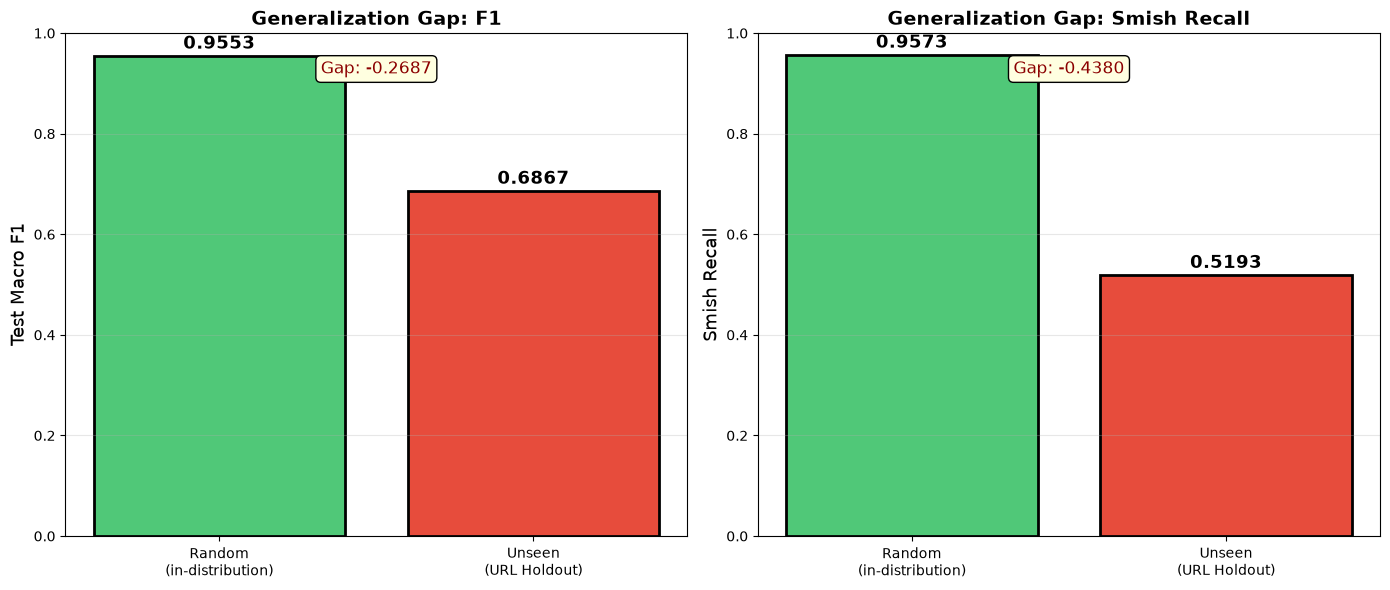

✅ Saved: results/figures/random_vs_unseen.png

                    KEY FINDING — MEMORIZATION PROOF
Random Split F1       : 0.9553
Unseen Split F1       : 0.6867
F1 Generalization Gap : -0.2687 (26.9%)

Random Smish Recall   : 0.9573
Unseen Smish Recall   : 0.5193
Recall Drop           : -0.4380 (43.8%)

🎯 CONCLUSION: Models memorize URL patterns rather than
   learning robust phishing intent.


In [8]:
# ============================================================
# RANDOM vs UNSEEN — Plot + Save (Paper Figure 1)
# ============================================================
import json
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1. Save comprehensive JSON ----------
comparison = {
    "random_split": result_random,
    "unseen_b1": result_unseen,
    "generalization_gap_f1": result_random['test_f1'] - result_unseen['test_f1'],
    "smish_recall_drop": result_random['smish_recall'] - result_unseen['smish_recall'],
    "interpretation": {
        "f1_gap_pct": round((result_random['test_f1'] - result_unseen['test_f1']) * 100, 2),
        "recall_gap_pct": round((result_random['smish_recall'] - result_unseen['smish_recall']) * 100, 2),
        "conclusion": "Models memorize URL patterns rather than learning robust phishing intent"
    }
}

with open("results/analysis/random_vs_unseen.json", "w") as f:
    json.dump(comparison, f, indent=2)
print("✅ Saved: results/analysis/random_vs_unseen.json")

# ---------- 2. Plot (2 subplots) ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

splits = ['Random\n(in-distribution)', 'Unseen\n(URL Holdout)']
f1s = [result_random['test_f1'], result_unseen['test_f1']]
recalls = [result_random['smish_recall'], result_unseen['smish_recall']]
colors = ['#50C878', '#E74C3C']

# ----- Plot 1: F1 -----
bars1 = axes[0].bar(splits, f1s, color=colors, edgecolor='black', linewidth=2)
for bar, v in zip(bars1, f1s):
    axes[0].annotate(
        f'{v:.4f}',
        xy=(bar.get_x() + bar.get_width()/2, v),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center', fontsize=13, fontweight='bold'
    )
axes[0].set_ylabel('Test Macro F1', fontsize=13)
axes[0].set_title('Generalization Gap: F1', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].grid(alpha=0.3, axis='y')
axes[0].annotate(
    f'Gap: -{f1s[0]-f1s[1]:.4f}',
    xy=(0.5, 0.92), xycoords='axes fraction',
    ha='center', fontsize=12, color='darkred',
    bbox=dict(boxstyle='round', facecolor='lightyellow')
)

# ----- Plot 2: Smish Recall -----
bars2 = axes[1].bar(splits, recalls, color=colors, edgecolor='black', linewidth=2)
for bar, v in zip(bars2, recalls):
    axes[1].annotate(
        f'{v:.4f}',
        xy=(bar.get_x() + bar.get_width()/2, v),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center', fontsize=13, fontweight='bold'
    )
axes[1].set_ylabel('Smish Recall', fontsize=13)
axes[1].set_title('Generalization Gap: Smish Recall', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].grid(alpha=0.3, axis='y')
axes[1].annotate(
    f'Gap: -{recalls[0]-recalls[1]:.4f}',
    xy=(0.5, 0.92), xycoords='axes fraction',
    ha='center', fontsize=12, color='darkred',
    bbox=dict(boxstyle='round', facecolor='lightyellow')
)

plt.tight_layout()
plt.savefig("results/figures/random_vs_unseen.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/figures/random_vs_unseen.png")

# ---------- 3. Print Summary ----------
print("\n" + "=" * 70)
print(" " * 20 + "KEY FINDING — MEMORIZATION PROOF")
print("=" * 70)
print(f"Random Split F1       : {result_random['test_f1']:.4f}")
print(f"Unseen Split F1       : {result_unseen['test_f1']:.4f}")
print(f"F1 Generalization Gap : -{f1s[0]-f1s[1]:.4f} ({(f1s[0]-f1s[1])*100:.1f}%)")
print(f"\nRandom Smish Recall   : {result_random['smish_recall']:.4f}")
print(f"Unseen Smish Recall   : {result_unseen['smish_recall']:.4f}")
print(f"Recall Drop           : -{recalls[0]-recalls[1]:.4f} ({(recalls[0]-recalls[1])*100:.1f}%)")
print("=" * 70)
print("\n🎯 CONCLUSION: Models memorize URL patterns rather than")
print("   learning robust phishing intent.")
print("=" * 70)

In [9]:
import json
with open("results/analysis/robustness_results.json") as f:
    d = json.load(f)
for r in d['results']:
    print(f"{r['condition']:15s} | F1 = {r['macro_f1']:.4f} | Recall = {r['smish_recall']:.4f}")

Clean           | F1 = 0.7463 | Recall = 0.5888
Typo (5%)       | F1 = 0.7330 | Recall = 0.5675
Extra Spaces    | F1 = 0.7463 | Recall = 0.5888
Case Flip       | F1 = 0.7163 | Recall = 0.5438
Mixed           | F1 = 0.6990 | Recall = 0.5146
